In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table

# Lagoon Data

In [2]:
# Data from observations

pix  = 0
dist = 1250 #parsecs
pc   = dist*(2*np.pi) / (360 * 60 * 60)
s0   = (0.9*pc)
pc , s0

(0.0060601710138692, 0.00545415391248228)

In [3]:
points_of_interest = {
    "HD 164536": [270.6609, -24.2554],
    "7 Sgr": [270.7129, -24.2825],
    "Herschel 36": [270.9180, -24.3785],
    "9 Sgr": [270.9685, -24.3607],
    "HD 164816": [270.9869, -24.3126],
    "HD 164865": [271.0634, -24.1834],
    "M8E-IR": [271.2244, -24.4448],
    "HD 165052": [271.2940, -24.3986],
    "HD 165246": [271.5195, -24.1955],
}
def mark_points(ax):
    for label, c in points_of_interest.items():
        ax.plot(c[0], c[1], marker='+', markersize='12', color='k')

# User function

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_line_panels(line_df, *, mark_func=None, s=25,
                     xcol="RAdeg", ycol="DEdeg",
                     flux_col="log_F", vcol="V_mean",
                     flux_cmap="magma", v_cmap="RdBu_r",
                     invert_ra=True, figsize=(14, 7),
                     titles=("Log Flux", "V_mean - <V_mean>"),
                     cbar_labels=("Flux", "V_mean - mean")):
    """
    Plot two panels for a given line DataFrame:
      (1) flux_col map
      (2) mean-subtracted vcol map

    Parameters
    ----------
    line_df : pandas.DataFrame
        Must contain xcol, ycol, flux_col, vcol.
    mark_func : callable or None
        Function like mark_points(ax) to annotate points on each axis.
    s : float
        Marker size for scatter.
    invert_ra : bool
        If True, invert x-axis (RA convention).
    """

    required = [xcol, ycol, flux_col, vcol]
    missing = [c for c in required if c not in line_df.columns]
    if missing:
        raise ValueError(f"Missing columns in line_df: {missing}")

    with sns.axes_style("darkgrid"):
        fig, ax = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

        # Panel 1: log flux
        sc1 = ax[0].scatter(line_df[xcol], line_df[ycol], s=s, c=line_df[flux_col], cmap=flux_cmap)
        if invert_ra:
            ax[0].invert_xaxis()
        ax[0].set_xlabel("RA (deg)")
        ax[0].set_ylabel("Dec (deg)")
        ax[0].set_title(titles[0])
        if callable(mark_func):
            mark_func(ax[0])
        fig.colorbar(sc1, ax=ax[0], label=cbar_labels[0])

        # Panel 2: mean-subtracted velocity
        v1 = line_df[vcol] - line_df[vcol].mean()
        sc2 = ax[1].scatter(line_df[xcol], line_df[ycol], s=s, c=v1, cmap=v_cmap)
        if invert_ra:
            ax[1].invert_xaxis()
        ax[1].set_xlabel("RA (deg)")
        ax[1].set_ylabel("Dec (deg)")
        ax[1].set_title(titles[1])
        if callable(mark_func):
            mark_func(ax[1])
        fig.colorbar(sc2, ax=ax[1], label=cbar_labels[1])

    return fig, ax


# H alfa

In [5]:
name =  "FLA-M8-H"

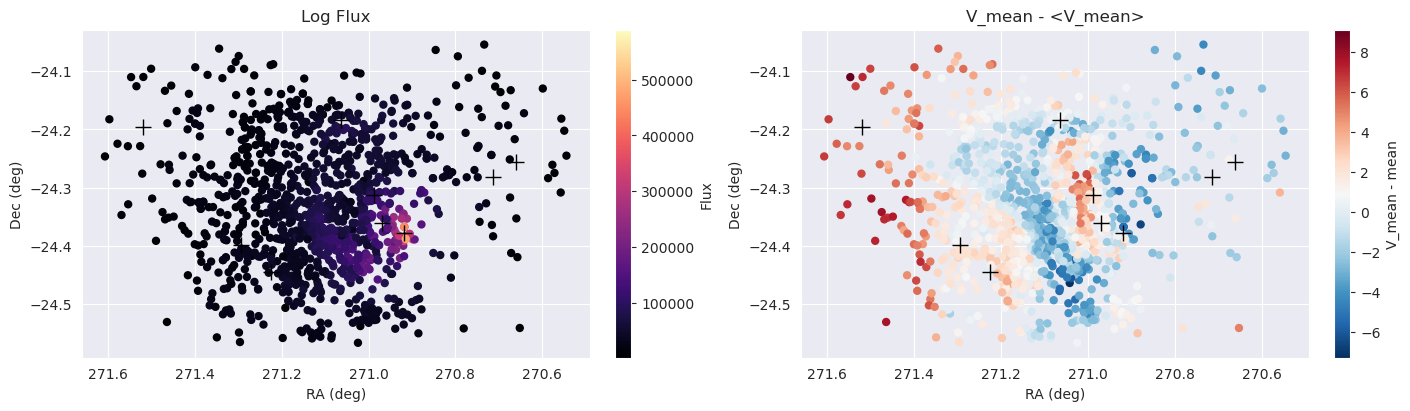

In [8]:
_data = json.load(open('observations/'+ name + '-l.json'))
_line = pd.DataFrame(_data[name])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']

N = np.sqrt((_line.RAdeg.max()-_line.RAdeg.min())*(_line.DEdeg.max()-_line.DEdeg.min())) * pc * 3600

t         = Table.from_pandas(_line.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name)
sig       = _line['V_mean'].std()

primary = fits.PrimaryHDU()
primary.header["INSTR"]     = "FLAMES"
primary.header["AUTHOR"]    = ("J. Garcia-Vazquez", "File creator")
#primary.header["m3D"]       = (m3D, "k = 3 + m3D")
#primary.header["ra"]        = (ra, "Artificial correlation length")
primary.header["sig"]       = (sig, "Standard deviation vel artificial map")
primary.header["sig2"]      = (sig**2, "Vel Variance artificial map")
primary.header["s0"]        = (s0, "Atmospheric seeing")
#primary.header["noise"]     = (noise, "Instrumental noise")
primary.header["box_size"]  = (N, "Observational box_size")
primary.header["pc"]        = (pc, "parsec convertion")
primary.header["pix"]       = (pix, "Instrument pixel scale")
primary.header["LINE"]      = ("H_I-6563", "Emission line name")
primary.header["BINSIZE"]   = (0, "Spatial binning factor")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

hdul = fits.HDUList([primary, table_hdu])
hdul.writeto(name + ".fits", overwrite=True)

fig, ax = plot_line_panels(_line, mark_func=mark_points,  figsize=(14, 4))
plt.show()

# [SII]

In [10]:
name =  "FLA-M8-S"

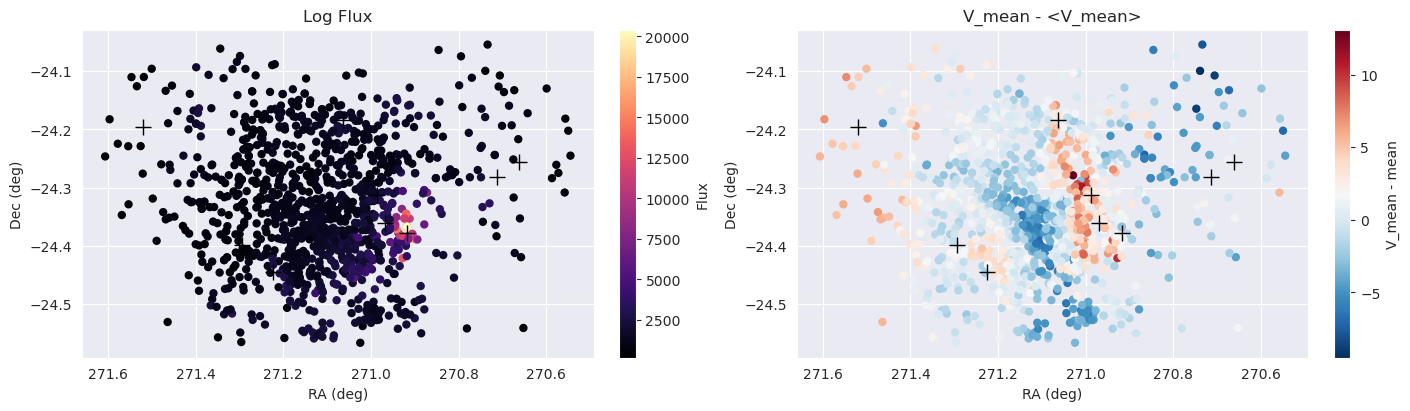

In [11]:
_data = json.load(open('observations/'+ name + '-l.json'))
_line = pd.DataFrame(_data[name])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']

N = np.sqrt((_line.RAdeg.max()-_line.RAdeg.min())*(_line.DEdeg.max()-_line.DEdeg.min())) * pc * 3600

t         = Table.from_pandas(_line.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name)
sig       = _line['V_mean'].std()

primary = fits.PrimaryHDU()
primary.header["INSTR"]     = "FLAMES"
primary.header["AUTHOR"]    = ("J. Garcia-Vazquez", "File creator")
#primary.header["m3D"]       = (m3D, "k = 3 + m3D")
#primary.header["ra"]        = (ra, "Artificial correlation length")
primary.header["sig"]       = (sig, "Standard deviation vel artificial map")
primary.header["sig2"]      = (sig**2, "Vel Variance artificial map")
primary.header["s0"]        = (s0, "Atmospheric seeing")
#primary.header["noise"]     = (noise, "Instrumental noise")
primary.header["box_size"]  = (N, "Observational box_size")
primary.header["pc"]        = (pc, "parsec convertion")
primary.header["pix"]       = (pix, "Instrument pixel scale")
primary.header["LINE"]      = ("H_I-6563", "Emission line name")
primary.header["BINSIZE"]   = (0, "Spatial binning factor")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

hdul = fits.HDUList([primary, table_hdu])
hdul.writeto(name + ".fits", overwrite=True)

fig, ax = plot_line_panels(_line, mark_func=mark_points,  figsize=(14, 4))
plt.show()

# [NII]

In [12]:
name =  "FLA-M8-N"

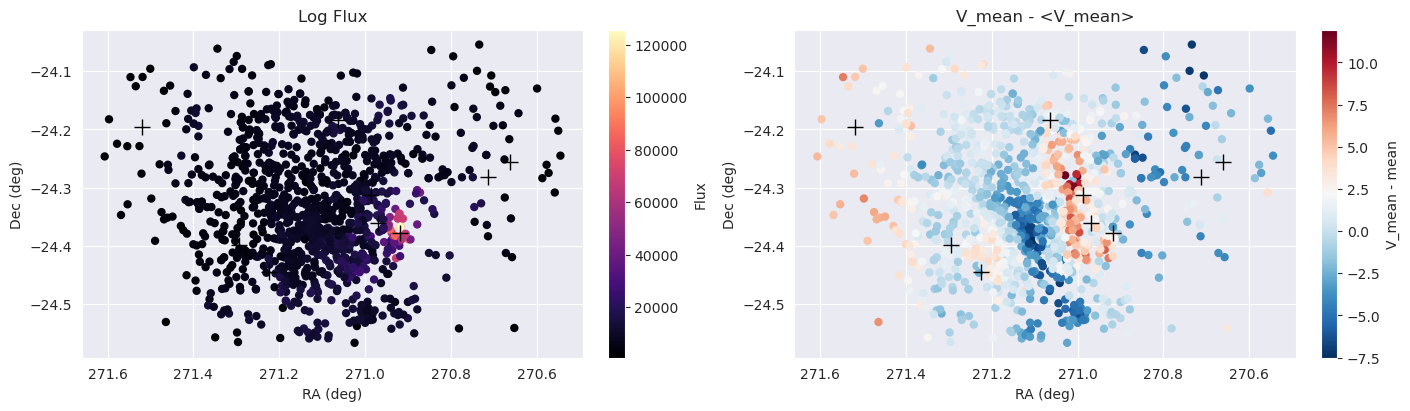

In [13]:
_data = json.load(open('observations/'+ name + '-l.json'))
_line = pd.DataFrame(_data[name])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']

N = np.sqrt((_line.RAdeg.max()-_line.RAdeg.min())*(_line.DEdeg.max()-_line.DEdeg.min())) * pc * 3600

t         = Table.from_pandas(_line.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name)
sig       = _line['V_mean'].std()

primary = fits.PrimaryHDU()
primary.header["INSTR"]     = "FLAMES"
primary.header["AUTHOR"]    = ("J. Garcia-Vazquez", "File creator")
#primary.header["m3D"]       = (m3D, "k = 3 + m3D")
#primary.header["ra"]        = (ra, "Artificial correlation length")
primary.header["sig"]       = (sig, "Standard deviation vel artificial map")
primary.header["sig2"]      = (sig**2, "Vel Variance artificial map")
primary.header["s0"]        = (s0, "Atmospheric seeing")
#primary.header["noise"]     = (noise, "Instrumental noise")
primary.header["box_size"]  = (N, "Observational box_size")
primary.header["pc"]        = (pc, "parsec convertion")
primary.header["pix"]       = (pix, "Instrument pixel scale")
primary.header["LINE"]      = ("H_I-6563", "Emission line name")
primary.header["BINSIZE"]   = (0, "Spatial binning factor")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

hdul = fits.HDUList([primary, table_hdu])
hdul.writeto(name + ".fits", overwrite=True)

fig, ax = plot_line_panels(_line, mark_func=mark_points,  figsize=(14, 4))
plt.show()